# PGNN v16 — Two-Sided Gate Prior (hot->physics, DSA->data) — Al 6011-O Flow Stress

**v16 = v15 + `L_gate2`** (two-sided gate prior). This notebook trains **ONLY** the new config `hybrid+gp2`
(same harness, same 8 seeds, same folds) and **merges** with the v15 result CSVs when they are attached
(`stepC_loco_hybrid_raw.csv`, `stepC_loto_hybrid_raw.csv`, `stepC_random_hybrid_raw.csv`, `stepC_percondition_hybrid_raw.csv`).

Rationale: v15 showed the one-sided gate prior cannot learn to distrust physics in the DSA regime
(RT–150 °C, serrated flow / negative SRS in Al-Mg-Si) when those folds are held out.
The two-sided prior encodes that metallurgical knowledge directly: **g→1 for T≥250 °C, g→0 for T≤150 °C**.

## 1 · Imports & Configuration

In [1]:
from __future__ import annotations
import copy, math, os, random, time, warnings, itertools
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
warnings.filterwarnings("ignore")
R_GAS = 8.314  # J/(mol K)

@dataclass
class Config:
    # --- paths ---
    data_path: str = "/kaggle/input/datasets/jpcnvn/downsampled-data/al6011_downsampled_full.xlsx"   # auto-searches for al6011_downsampled_full.xlsx
    output_dir: str = "."
    # --- data ---
    feature_cols: List[str] = field(default_factory=lambda: ["T_K", "ln_sr", "eps_true"])
    target_col: str = "sigma_true"
    val_ratio: float = 0.15
    # --- model ---
    hidden_dims: List[int] = field(default_factory=lambda: [128, 128, 64])
    dropout: float = 0.1
    # --- hybrid (v13) ---
    free_hidden_dims: List[int] = field(default_factory=lambda: [64, 64])
    gate_hidden: int = 16
    gate_bias_init: float = 2.0      # sigmoid(2) ~ 0.88 -> start physics-dominant
    lambda_gate: float = 0.1         # fixed weight of the gate prior (NO uncertainty weighting: v11/v12 showed it is a confound)
    hot_T_min_K: float = 523.15      # T>=250C = regime where the gate prior trusts physics
    cold_T_max_K: float = 423.15     # v16: T<=150C = DSA regime — two-sided prior trusts the DATA expert
    # --- representation (optional lnZ feature; see Section 6) ---
    Q0_J: float = 156_800.0          # fallback; measured from THIS dataset (per-strain sinh-Arrhenius, eps 0.05-0.19)
    # --- training ---
    batch_size: int = 64
    epochs: int = 500
    patience: int = 60
    lr: float = 1e-3
    weight_decay: float = 1e-5
    scheduler_factor: float = 0.5
    scheduler_patience: int = 30
    grad_clip: float = 10.0
    # --- physics (legacy terms kept for compatibility) ---
    scam_temp_min_K: float = 523.0
    scam_eps_min: float = 0.05
    scam_eps_max: float = 0.19
    mono_srate_hot_only: bool = True
    smooth_eps_grid: Tuple[float,float,int] = (0.05, 0.65, 60)
    # --- experiment control ---
    seed: int = 42
    seeds: List[int] = field(default_factory=lambda: [42, 1, 2, 3, 4, 5, 6, 7])
    quick: bool = False   # True = smoke run. Set False for the full study.
    @property
    def device(self): return torch.device("cuda" if torch.cuda.is_available() else "cpu")

CFG = Config()
if CFG.quick:
    CFG.epochs = 60
print("Device:", CFG.device, "| epochs:", CFG.epochs, "| quick:", CFG.quick, "| seeds:", CFG.seeds)


Device: cuda | epochs: 500 | quick: False | seeds: [42, 1, 2, 3, 4, 5, 6, 7]


## 2 · Reproducibility

In [2]:
def seed_everything(seed: int = None) -> None:
    seed = CFG.seed if seed is None else seed
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

## 3 · Data Loading

In [3]:
def _find_data_path(p: str, fname: str = "al6011_downsampled_full.xlsx") -> str:
    """Locate the data file whether `p` is the file itself, a directory, or wrong.
    Preference: exact file -> exact filename anywhere -> *downsampled*.xlsx -> any .xlsx."""
    if os.path.isfile(p):
        return p
    roots = ([p] if os.path.isdir(p) else []) + ["/kaggle/input", "."]
    cands = []
    for root in roots:
        if not os.path.isdir(root):
            continue
        for dp, _, fns in os.walk(root):
            for fn in fns:
                if fn.lower().endswith((".xlsx", ".xls")):
                    cands.append(os.path.join(dp, fn))
    if not cands:
        raise FileNotFoundError(f"No .xlsx found at/near {p} or /kaggle/input")
    for c in cands:
        if os.path.basename(c) == fname:
            return c
    for c in cands:
        if "downsampled" in os.path.basename(c).lower():
            return c
    return cands[0]

CFG.data_path = _find_data_path(CFG.data_path)
print("Using data file:", CFG.data_path)
xf = pd.ExcelFile(CFG.data_path)
sheets = [s for s in xf.sheet_names if s != "Summary"]
data = pd.concat([pd.read_excel(CFG.data_path, sheet_name=s).assign(condition=s) for s in sheets],
                 ignore_index=True)
print(f"Loaded {len(data):,} points | {data['condition'].nunique()} conditions")

X_all   = data[CFG.feature_cols].values.astype(np.float32)
y_all   = data[CFG.target_col].values.astype(np.float32).reshape(-1, 1)
T_K_raw = data["T_K"].values.astype(np.float32)
sr_raw  = data["strain_rate"].values.astype(np.float32)
eps_raw = data["eps_true"].values.astype(np.float32)
cond_arr= data["condition"].values
ALL_CONDS = list(data["condition"].unique())

Using data file: /kaggle/input/datasets/jpcnvn/downsampled-data/al6011_downsampled_full.xlsx
Loaded 1,982 points | 21 conditions


## 4 · Splits — Random (reference) and Leave-One-Condition-Out (honest)

`random_split` reproduces the original within-condition shuffle (interpolation — optimistic).
`loco_split` holds out one entire condition (extrapolation — the metric that actually tests generalization).
A held-out *temperature* or *strain-rate* variant is also provided for harder extrapolation.

In [4]:
def random_split(seed=CFG.seed, train_ratio=0.70, val_ratio=CFG.val_ratio):
    rng = np.random.default_rng(seed)
    tr, va, te = [], [], []
    for c in ALL_CONDS:
        idx = np.where(cond_arr == c)[0].copy(); rng.shuffle(idx)
        n = len(idx); ntr = int(train_ratio*n); nva = int(val_ratio*n)
        tr += list(idx[:ntr]); va += list(idx[ntr:ntr+nva]); te += list(idx[ntr+nva:])
    return np.array(tr), np.array(va), np.array(te)

def loco_split(holdout_condition, seed=CFG.seed, val_ratio=CFG.val_ratio):
    rng = np.random.default_rng(seed)
    te = np.where(cond_arr == holdout_condition)[0]
    pool = np.where(cond_arr != holdout_condition)[0].copy(); rng.shuffle(pool)
    nva = int(val_ratio*len(pool))
    return pool[nva:], pool[:nva], te

def loto_split(holdout_T_C, seed=CFG.seed, val_ratio=CFG.val_ratio):
    """Leave-one-temperature-out (harder)."""
    rng = np.random.default_rng(seed)
    te = np.where(data["T_C"].values == holdout_T_C)[0]
    pool = np.where(data["T_C"].values != holdout_T_C)[0].copy(); rng.shuffle(pool)
    nva = int(val_ratio*len(pool))
    return pool[nva:], pool[:nva], te

## 5 · SCAM Polynomial (parameter validation + optional legacy term)

SCAM is **not** used as the main physics target (redundant). It is kept to (a) reproduce the legacy
`L_scam` term for the ablation comparison and (b) validate learned parameters against a classical fit.
Coefficients below are the user's fitted polynomials; they are physically sane inside ε∈[0.05,0.19].

In [5]:
SCAM_POLY_COEFFS = {
 "alpha": np.array([ 2.990838465670e+04,-1.994069281431e+04, 5.345762450621e+03,-7.350303313298e+02,
                     5.448368675032e+01,-2.063309588944e+00, 5.051186723984e-02]),
 "n":     np.array([-7.812215710077e+05, 2.343228580944e+05, 4.087839767037e+04,-2.591299218747e+04,
                     4.249708974788e+03,-3.168428320818e+02, 1.508120816407e+01]),
 "Q":     np.array([-8.543584880384e+10, 5.238248618259e+10,-1.249643528684e+10, 1.436699072794e+09,
                    -7.644242300049e+07, 1.055736379502e+06, 1.900591723054e+05]),
 "lnA":   np.array([-2.689844217277e+07, 1.687345535442e+07,-4.163261535534e+06, 5.066408364188e+05,
                    -3.055325125124e+04, 7.305787733034e+02, 2.523144522408e+01]),
}
def scam_sigma_np(eps, T_K, sr):
    a=np.polyval(SCAM_POLY_COEFFS["alpha"],eps); n=np.polyval(SCAM_POLY_COEFFS["n"],eps)
    Q=np.polyval(SCAM_POLY_COEFFS["Q"],eps);     lnA=np.polyval(SCAM_POLY_COEFFS["lnA"],eps)
    Z = sr*np.exp(Q/(R_GAS*T_K))
    return (1.0/a)*np.arcsinh((Z/np.exp(lnA))**(1.0/n))

# precompute SCAM target + validity mask once (used only if 'scam' term is active)
_scam_raw = scam_sigma_np(eps_raw, T_K_raw, sr_raw).astype(np.float64)
SCAM_VALID = (np.isfinite(_scam_raw) & (T_K_raw >= CFG.scam_temp_min_K)
              & (eps_raw >= CFG.scam_eps_min) & (eps_raw <= CFG.scam_eps_max))
_scam_raw[~SCAM_VALID] = 0.0
SCAM_SIGMA = np.clip(_scam_raw, 0, 500).astype(np.float32).reshape(-1,1)
print(f"SCAM valid points: {SCAM_VALID.sum()}/{len(SCAM_VALID)} ({100*SCAM_VALID.mean():.1f}%)")

SCAM valid points: 435/1982 (21.9%)


## 6 · Per-fold Data Prep (scalers fit on train only — no leakage)

`feature_mode="base"` -> (T_K, ln_sr, eps) exactly as v12. `feature_mode="lnZ"` -> adds ln Z = ln(sr) + Q0/(R*T) as a 4th feature, where **Q0 is re-fitted on that fold's TRAINING points only** (per-strain sinh-Arrhenius regression) so LOCO/LOTO stay leakage-free.


In [6]:
def fit_Q0_train(tr_idx) -> float:
    """Classical per-strain sinh-Arrhenius fit on TRAIN rows only (hot regime, valid eps window).
    ln(sr) = lnA + n*ln(sinh(alpha*sigma)) - (Q/R)*(1/T). Returns mean Q over strain levels [J/mol]."""
    df = data.iloc[np.asarray(tr_idx)]
    hot = df[df["T_K"] >= CFG.hot_T_min_K]
    Qs = []
    for eps0 in np.arange(0.05, 0.20, 0.02):
        rows = []
        for _, g in hot.groupby("condition"):
            g = g.sort_values("eps_true")
            if len(g) < 4 or g["eps_true"].min() > eps0 or g["eps_true"].max() < eps0:
                continue
            rows.append((g["T_K"].iloc[0], g["strain_rate"].iloc[0],
                         float(np.interp(eps0, g["eps_true"], g["sigma_true"]))))
        if len(rows) < 10:
            continue
        T, sr, sig = map(np.array, zip(*rows))
        best = None
        for a in np.arange(0.010, 0.041, 0.005):
            X = np.column_stack([np.log(np.sinh(a*sig)), 1.0/T, np.ones_like(T)])
            yv = np.log(sr)
            beta, *_ = np.linalg.lstsq(X, yv, rcond=None)
            r2 = 1 - ((yv - X@beta)**2).sum() / ((yv - yv.mean())**2).sum()
            if best is None or r2 > best[0]:
                best = (r2, -beta[1]*R_GAS)
        Qs.append(best[1])
    return float(np.mean(Qs)) if Qs else CFG.Q0_J

def _featurize(T_K, ln_sr, eps, mode="base", Q0=None):
    base = np.stack([T_K, ln_sr, eps], 1).astype(np.float32)
    if mode == "base":
        return base
    lnZ = (ln_sr + (Q0 or CFG.Q0_J)/(R_GAS*T_K)).astype(np.float32).reshape(-1, 1)
    return np.concatenate([base, lnZ], 1)

@dataclass
class Fold:
    tr: np.ndarray; va: np.ndarray; te: np.ndarray
    sx: StandardScaler; sy: StandardScaler
    smooth_grid: torch.Tensor
    device: torch.device
    X: np.ndarray            # feature matrix for THIS fold (depends on feature_mode)
    Q0: Optional[float]
    feature_mode: str

def prep_fold(tr, va, te, feature_mode="base") -> Fold:
    Q0 = fit_Q0_train(tr) if feature_mode != "base" else None
    X = _featurize(T_K_raw, np.log(sr_raw), eps_raw, feature_mode, Q0)
    sx = StandardScaler().fit(X[tr]); sy = StandardScaler().fit(y_all[tr])
    lo, hi, g = CFG.smooth_eps_grid
    eg = np.linspace(lo, hi, g).astype(np.float32)
    grid_raw = _featurize(np.full_like(eg, 723.15), np.full_like(eg, np.log(0.01)), eg,
                          feature_mode, Q0)
    grid = torch.tensor(sx.transform(grid_raw).astype(np.float32), device=CFG.device)
    return Fold(tr, va, te, sx, sy, grid, CFG.device, X, Q0, feature_mode)

def make_loader(F: Fold, idx, shuffle):
    t = (torch.tensor(F.sx.transform(F.X[idx]).astype(np.float32)),
         torch.tensor(((y_all[idx]-F.sy.mean_[0])/F.sy.scale_[0]).astype(np.float32)),
         torch.tensor(T_K_raw[idx].reshape(-1,1)), torch.tensor(sr_raw[idx].reshape(-1,1)),
         torch.tensor(eps_raw[idx].reshape(-1,1)),
         torch.tensor(((SCAM_SIGMA[idx]-F.sy.mean_[0])/F.sy.scale_[0]).astype(np.float32)),
         torch.tensor(SCAM_VALID[idx].astype(np.float32).reshape(-1,1)))
    bs = CFG.batch_size if shuffle else 256
    return DataLoader(TensorDataset(*t), batch_size=bs, shuffle=shuffle)


## 7 · Models — HybridPGNN (physics expert), FreeNet (data expert), GatedHybridPGNN (mixture)

The gate g(x) in [0,1] blends the two experts: **sigma = g*sigma_phys + (1-g)*sigma_free**. Initialized physics-dominant (g~0.88). The free branch CAN represent negative strain-rate sensitivity (DSA at RT/150) — the Arrhenius branch cannot. So the gate has a real decision to make, and the gate prior (Section 8) is a physics loss that is finally non-redundant.


In [7]:
PARAM_BOUNDS = {"alpha": (0.005, 0.045), "n": (2.0, 8.0), "Q": (130_000, 90_000), "lnA": (15.0, 25.0)}

class HybridPGNN(nn.Module):
    """Physics expert: NN -> (alpha, n, Q, lnA) -> sinh-Arrhenius -> sigma. Unchanged from v12."""
    def __init__(self, input_dim=3, hidden_dims=None, dropout=CFG.dropout):
        super().__init__()
        hidden_dims = hidden_dims or CFG.hidden_dims
        layers, d = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]; d = h
        self.backbone = nn.Sequential(*layers)
        self.heads = nn.ModuleDict({k: nn.Linear(hidden_dims[-1], 1) for k in PARAM_BOUNDS})

    def raw_params(self, x_scaled):
        h = self.backbone(x_scaled)
        return {k: torch.sigmoid(self.heads[k](h)) for k in PARAM_BOUNDS}

    def forward(self, x_scaled, T_K, sr, eps):
        h = self.backbone(x_scaled)
        p = {k: lo + rng_*torch.sigmoid(self.heads[k](h)) for k,(lo,rng_) in PARAM_BOUNDS.items()}
        Z   = sr*torch.exp(torch.clamp(p["Q"]/(R_GAS*T_K), max=80.0))
        rat = torch.clamp(Z/torch.exp(p["lnA"]), min=1e-10, max=1e30)
        sigma = (1.0/p["alpha"])*torch.arcsinh(rat**(1.0/p["n"]))
        return sigma, p

class FreeNet(nn.Module):
    """Data expert: plain MLP -> sigma (in target-scaled units, un-scaled at output).
    Unconstrained: CAN model DSA / negative strain-rate sensitivity."""
    def __init__(self, input_dim=3, hidden_dims=None, dropout=CFG.dropout):
        super().__init__()
        hidden_dims = hidden_dims or CFG.free_hidden_dims
        layers, d = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]; d = h
        layers += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*layers)
        self.y_mean, self.y_scale = 0.0, 1.0

    def set_output_scale(self, mean, scale):
        self.y_mean, self.y_scale = float(mean), float(scale)

    def forward(self, x_scaled, T_K=None, sr=None, eps=None):
        z = self.net(x_scaled)
        return z*self.y_scale + self.y_mean, {}

class GatedHybridPGNN(nn.Module):
    """sigma = g(x)*sigma_phys + (1-g(x))*sigma_free. Gate init physics-dominant."""
    def __init__(self, input_dim=3):
        super().__init__()
        self.phys = HybridPGNN(input_dim=input_dim)
        self.free = FreeNet(input_dim=input_dim)
        self.gate = nn.Sequential(nn.Linear(input_dim, CFG.gate_hidden), nn.Tanh(),
                                  nn.Linear(CFG.gate_hidden, 1))
        with torch.no_grad():
            self.gate[-1].bias.fill_(CFG.gate_bias_init)

    def set_output_scale(self, mean, scale):
        self.free.set_output_scale(mean, scale)

    def raw_params(self, x_scaled):          # passthrough for legacy losses
        return self.phys.raw_params(x_scaled)

    def gate_value(self, x_scaled):
        return torch.sigmoid(self.gate(x_scaled))

    def forward(self, x_scaled, T_K, sr, eps):
        s_p, p = self.phys(x_scaled, T_K, sr, eps)
        s_f, _ = self.free(x_scaled)
        g = self.gate_value(x_scaled)
        sigma = g*s_p + (1.0-g)*s_f
        out = dict(p); out.update({"gate": g, "sigma_phys": s_p, "sigma_free": s_f})
        return sigma, out

MODEL_FACTORY = {
    "pgnn":   lambda input_dim: HybridPGNN(input_dim=input_dim),
    "free":   lambda input_dim: FreeNet(input_dim=input_dim),
    "hybrid": lambda input_dim: GatedHybridPGNN(input_dim=input_dim),
}


## 8 · Losses

`L_gate` is the new, non-redundant physics prior: where T>=250 C (Arrhenius-trusted regime) it penalizes (1-g)^2, i.e. *"use the physics expert where the physics is valid"*. Below 250 C the gate is free — the data decides. All configs use **fixed weighting** (uncertainty weighting was shown in v11/v12 to be a confound). Legacy terms (mono/smooth/consistency/scam) kept for reference.


In [8]:
_crit = nn.MSELoss()
def _scale_sigma(raw, F): return (raw - F.sy.mean_[0]) / F.sy.scale_[0]

def L_data(model, F, xs, ys, T, sr, eps):
    sigma, _ = model(xs, T, sr, eps)
    return _crit(_scale_sigma(sigma, F), ys), sigma

def L_gate(model, xs, T):
    """Gate prior: trust the physics expert where T >= hot_T_min_K."""
    g = model.gate_value(xs)
    hot = (T >= CFG.hot_T_min_K).float()
    denom = torch.clamp(hot.sum(), min=1.0)
    return (((1.0 - g)**2) * hot).sum() / denom

def L_gate2(model, xs, T):
    """v16 two-sided gate prior: trust physics where T >= hot_T_min_K,
    trust the DATA expert where T <= cold_T_max_K (DSA regime: serrated flow /
    negative strain-rate sensitivity in Al-Mg-Si at RT..150C — sinh-Arrhenius is invalid there)."""
    g = model.gate_value(xs)
    hot  = (T >= CFG.hot_T_min_K).float()
    cold = (T <= CFG.cold_T_max_K).float()
    l_hot  = (((1.0 - g)**2) * hot ).sum() / torch.clamp(hot.sum(),  min=1.0)
    l_cold = ((g**2)         * cold).sum() / torch.clamp(cold.sum(), min=1.0)
    return l_hot + l_cold


# ---- legacy terms (kept for compatibility / reference) ----
def L_consistency(model, xs):
    xs = xs.clone().requires_grad_(True)
    p = model.raw_params(xs); tot = 0.0
    for k in PARAM_BOUNDS:
        g, = torch.autograd.grad(p[k].sum(), xs, create_graph=True)
        tot = tot + (g[:,0]**2).mean() + (g[:,1]**2).mean()
    return tot/len(PARAM_BOUNDS)

def L_smooth(model, F):
    p = model.raw_params(F.smooth_grid); tot = 0.0
    for k in PARAM_BOUNDS:
        v = p[k].squeeze(-1); d2 = v[2:]-2*v[1:-1]+v[:-2]
        tot = tot + (d2**2).mean()
    return tot/len(PARAM_BOUNDS)

def L_scam(sigma_scaled, scam_scaled, mask):
    nv = mask.sum()
    if nv == 0: return torch.tensor(0.0, device=sigma_scaled.device)
    return ((sigma_scaled - scam_scaled)**2 * mask).sum()/nv

class UncertaintyWeighter(nn.Module):
    """Kept for reference only — v11/v12 showed this is a confound vs fixed weighting."""
    def __init__(self, names):
        super().__init__()
        self.log_sigma = nn.ParameterDict({n: nn.Parameter(torch.zeros(())) for n in names})
    def combine(self, losses: Dict[str, torch.Tensor]):
        return sum(0.5*torch.exp(-2*self.log_sigma[n])*l + self.log_sigma[n] for n, l in losses.items())
    def weights(self):
        return {n: float(torch.exp(-2*p).detach()) for n, p in self.log_sigma.items()}


## 9 · Training Engine

`active` lists which physics terms are on (subset of `consistency`,`smooth`,`mono`,`scam`).
`weighting` is `fixed` (uses `lambdas`) or `uncertainty`. Data term always on.

In [9]:
@dataclass
class History:
    train: List[float] = field(default_factory=list)
    val:   List[float] = field(default_factory=list)
    terms: Dict[str, List[float]] = field(default_factory=dict)
    best_epoch: int = 0

def train_model(F: Fold, active=(), weighting="fixed", lambdas=None, seed=CFG.seed,
                run_name="run", verbose_every=0, model_kind="pgnn"):
    seed_everything(seed)
    lambdas = lambdas or {}
    model = MODEL_FACTORY[model_kind](F.X.shape[1]).to(F.device)
    if hasattr(model, "set_output_scale"):
        model.set_output_scale(F.sy.mean_[0], F.sy.scale_[0])
    names = ["data"] + list(active)
    uw = UncertaintyWeighter(names).to(F.device) if weighting == "uncertainty" else None
    params = list(model.parameters()) + (list(uw.parameters()) if uw else [])
    opt = torch.optim.Adam(params, lr=CFG.lr, weight_decay=CFG.weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min",
                factor=CFG.scheduler_factor, patience=CFG.scheduler_patience, min_lr=1e-6)
    tl = make_loader(F, F.tr, True); vl = make_loader(F, F.va, False)
    hist = History(); best_val = math.inf; best_state = None; wait = 0
    dev = F.device
    for epoch in range(CFG.epochs):
        model.train(); run_terms = {n: 0.0 for n in names}; nseen = 0
        for xs, ys, T, sr, eps, scam, mask in tl:
            xs, ys = xs.to(dev), ys.to(dev); T, sr, eps = T.to(dev), sr.to(dev), eps.to(dev)
            scam, mask = scam.to(dev), mask.to(dev)
            ld, sigma = L_data(model, F, xs, ys, T, sr, eps)
            losses = {"data": ld}
            if "gate"        in active: losses["gate"]        = L_gate(model, xs, T)
            if "gate2"       in active: losses["gate2"]       = L_gate2(model, xs, T)
            if "consistency" in active: losses["consistency"] = L_consistency(model, xs)
            if "smooth"      in active: losses["smooth"]      = L_smooth(model, F)
            if "scam"        in active: losses["scam"]        = L_scam(_scale_sigma(sigma, F), scam, mask)
            if weighting == "uncertainty":
                total = uw.combine(losses)
            else:
                total = ld + sum(lambdas.get(n, 0.1)*losses[n] for n in active)
            opt.zero_grad(); total.backward()
            nn.utils.clip_grad_norm_(params, CFG.grad_clip); opt.step()
            bs = len(xs); nseen += bs
            for n in names: run_terms[n] += float(losses[n])*bs
        for n in names: hist.terms.setdefault(n, []).append(run_terms[n]/nseen)
        hist.train.append(hist.terms["data"][-1])
        model.eval(); vs = 0.0
        with torch.no_grad():
            for xs, ys, T, sr, eps, *_ in vl:
                xs, ys = xs.to(dev), ys.to(dev); T, sr, eps = T.to(dev), sr.to(dev), eps.to(dev)
                s, _ = model(xs, T, sr, eps)
                vs += _crit(_scale_sigma(s, F), ys).item()*len(xs)
        vloss = vs/len(F.va); hist.val.append(vloss); sched.step(vloss)
        if vloss < best_val:
            best_val, hist.best_epoch, wait = vloss, epoch, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
        if verbose_every and ((epoch+1) % verbose_every == 0 or epoch == 0):
            extra = "  ".join(f"{n}={hist.terms[n][-1]:.4g}" for n in names)
            print(f"  [{run_name}] ep{epoch+1:4d} val={vloss:.5f}  {extra}")
        if wait >= CFG.patience:
            break
    model.load_state_dict(best_state); model.eval()
    return model, hist


## 10 · Evaluation Helpers

In [10]:
def predict(model, F, idx):
    Xs = torch.tensor(F.sx.transform(F.X[idx]).astype(np.float32), device=F.device)
    T  = torch.tensor(T_K_raw[idx].reshape(-1,1), device=F.device)
    sr = torch.tensor(sr_raw[idx].reshape(-1,1), device=F.device)
    eps= torch.tensor(eps_raw[idx].reshape(-1,1), device=F.device)
    with torch.no_grad(): sigma, params = model(Xs, T, sr, eps)
    return sigma.cpu().numpy(), {k: v.cpu().numpy() for k, v in params.items()}

def aare(yt, yp, floor=5.0):
    m = yt.flatten() > floor
    return float(np.mean(np.abs((yt[m]-yp[m])/yt[m]))*100) if m.sum() else float("nan")

def metrics(yt, yp):
    return {"r2": float(r2_score(yt, yp)),
            "rmse": float(np.sqrt(mean_squared_error(yt, yp))),
            "aare": aare(yt, yp)}

def eval_on(model, F, idx):
    yp, _ = predict(model, F, idx); return metrics(y_all[idx], yp)


## 11 · Sanity Run — hybrid+gp2 on the worst DSA fold and one hot fold

In [11]:
seed_everything(CFG.seed)
# v16 sanity: the two-sided gate must (a) rescue the DSA fold, (b) not hurt the hot fold
for fold_c, label in [("RT-0_001", "DSA fold"), ("400-0_001", "hot fold")]:
    tr, va, te = loco_split(fold_c, CFG.seed); F = prep_fold(tr, va, te)
    m, _ = train_model(F, active=("gate2",), lambdas={"gate2": CFG.lambda_gate},
                       seed=CFG.seed, run_name=f"sanity/gp2-{fold_c}", model_kind="hybrid")
    print(f"LOCO {fold_c} HYBRID+GP2 ({label}):", {k: round(v,4) for k,v in eval_on(m, F, te).items()})

LOCO RT-0_001 HYBRID+GP2 (DSA fold): {'r2': 0.4172, 'rmse': 39.7999, 'aare': 31.8293}
LOCO 400-0_001 HYBRID+GP2 (hot fold): {'r2': 0.8482, 'rmse': 2.1398, 'aare': 8.5325}


## 12 · LOCO × Multi-seed driver — hybrid+gp2 ONLY (merge with v15 for the other configs)

In [12]:
from scipy import stats as _stats

FOLDS = (["400-0_001", "RT-0_1"] if CFG.quick else list(ALL_CONDS))

# v16: only the new config runs here. pgnn / ann / hybrid / hybrid+gp come from the v15 CSVs (Section 13).
CONFIGS = [
    ("hybrid+gp2", "hybrid", ("gate2",), "fixed", "base"),   # two-sided gate prior (hot->physics, DSA->data)
]
SEEDS = CFG.seeds
LAMBDAS = {"gate": CFG.lambda_gate, "gate2": CFG.lambda_gate}

def run_config(name, kind, active, weighting, feat):
    rows = []
    for seed in SEEDS:
        for fold_c in FOLDS:
            tr, va, te = loco_split(fold_c, seed)
            F = prep_fold(tr, va, te, feature_mode=feat)
            model, _ = train_model(F, active=active, weighting=weighting,
                                   lambdas=LAMBDAS, seed=seed,
                                   run_name=f"{name}/{fold_c}/s{seed}", model_kind=kind)
            m = eval_on(model, F, te)
            rows.append({"config": name, "seed": seed, "fold": fold_c, **m})
        print(f"  [{name}] seed {seed} done ({time.time()-t0:.0f}s elapsed)")
    return pd.DataFrame(rows)

t0 = time.time()
all_rows = pd.concat([run_config(*c) for c in CONFIGS], ignore_index=True)
all_rows.to_csv(f"{CFG.output_dir}/stepC_loco_gp2_raw.csv", index=False)
print(f"Done in {time.time()-t0:.0f}s | rows={len(all_rows)}")

  [hybrid+gp2] seed 42 done (953s elapsed)
  [hybrid+gp2] seed 1 done (2178s elapsed)
  [hybrid+gp2] seed 2 done (3258s elapsed)
  [hybrid+gp2] seed 3 done (4148s elapsed)
  [hybrid+gp2] seed 4 done (5354s elapsed)
  [hybrid+gp2] seed 5 done (6475s elapsed)
  [hybrid+gp2] seed 6 done (7813s elapsed)
  [hybrid+gp2] seed 7 done (8770s elapsed)
Done in 8770s | rows=168


## 13 · Results — merge with v15, aggregated table, paired Δ, figure

Attach the v15 output CSVs (as a Kaggle dataset or in the working dir). If not found, the tables show `hybrid+gp2` alone.

!! stepC_loco_hybrid_raw.csv (v15) not found — showing hybrid+gp2 alone.

LOCO extrapolation (ALL 21 conditions held out) — mean +/- std over seeds x folds
                r2             rmse              aare         
              mean     std     mean      std     mean      std
config                                                        
hybrid+gp2  0.4634  0.5909  21.8657  25.0304  16.5494  11.1574

HOT folds (T>=250C):
               r2    aare
config                   
hybrid+gp2  0.591  12.462

DSA folds (RT+150C):
               r2    aare
config                   
hybrid+gp2  0.144  26.767


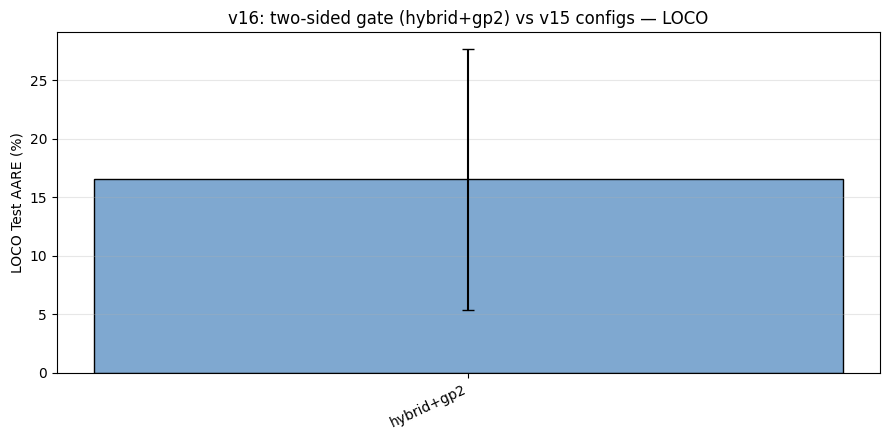

In [13]:
BASELINE = "pgnn"
ORDER = ["pgnn", "ann", "hybrid", "hybrid+gp", "hybrid+gp2"]

def _find_csv(fname):
    """Locate a v15 results csv: Kaggle input datasets, output dir, or cwd."""
    for root in ["/kaggle/input", CFG.output_dir, "."]:
        if not os.path.isdir(root): continue
        for dp, _, fns in os.walk(root):
            if fname in fns: return os.path.join(dp, fname)
    return None

v15_loco = _find_csv("stepC_loco_hybrid_raw.csv")
if v15_loco:
    loco_all = pd.concat([pd.read_csv(v15_loco), all_rows], ignore_index=True)
    print("Merged with v15 LOCO results:", v15_loco)
else:
    loco_all = all_rows.copy()
    print("!! stepC_loco_hybrid_raw.csv (v15) not found — showing hybrid+gp2 alone.")

order = [c for c in ORDER if c in set(loco_all["config"])]
agg = loco_all.groupby("config")[["r2","rmse","aare"]].agg(["mean","std"]).round(4).reindex(order)
print("\nLOCO extrapolation (ALL 21 conditions held out) — mean +/- std over seeds x folds")
print(agg)

is_dsa = loco_all["fold"].str.startswith("RT") | loco_all["fold"].str.startswith("150")
for label, sub in [("HOT folds (T>=250C)", loco_all[~is_dsa]), ("DSA folds (RT+150C)", loco_all[is_dsa])]:
    print(f"\n{label}:")
    print(sub.groupby("config")[["r2","aare"]].mean().round(3).reindex(order))

def paired_delta(df, name_a, name_b, keys, col="aare"):
    """Δ = a - b per (seed, fold); +ve means b improves on a."""
    a = df[df.config==name_a].set_index(keys)[col]
    b = df[df.config==name_b].set_index(keys)[col]
    d = (a - b).dropna()
    if len(d) < 2: return None
    try: p = float(_stats.ttest_rel(a.loc[d.index], b.loc[d.index]).pvalue)
    except Exception: p = float("nan")
    ci = 1.96*d.std()/max(len(d)**0.5,1)
    return d, ci, p

if BASELINE in order:
    print(f"\nPaired Δ AARE vs {BASELINE}  (+ve = improvement):")
    for name in order:
        if name == BASELINE: continue
        r = paired_delta(loco_all, BASELINE, name, ["seed","fold"])
        if r is None: continue
        d, ci, p = r
        verdict = "helps" if (d.mean()-ci)>0 else ("hurts" if (d.mean()+ci)<0 else "within noise")
        print(f"  {name:<12} Δ={d.mean():+.2f} ± {d.std():.2f} pp  "
              f"(95%CI ±{ci:.2f}; +ve {int((d>0).sum())}/{len(d)}; p={p:.3f}) -> {verdict}")

# headline check: does gp2 close the DSA gap vs the pure ANN?
if {"ann","hybrid+gp2"} <= set(order):
    r = paired_delta(loco_all[is_dsa], "ann", "hybrid+gp2", ["seed","fold"])
    if r:
        d, ci, p = r
        print(f"\nDSA folds only — hybrid+gp2 vs ann: Δ={d.mean():+.2f} ± {d.std():.2f} pp (95%CI ±{ci:.2f}; p={p:.3f})")
        print("   (>0 means gp2 now beats the pure ANN in its own regime — the v16 headline)")

fig, ax = plt.subplots(figsize=(9,4.5))
mu = agg[("aare","mean")].values; sd = agg[("aare","std")].values
ax.bar(range(len(order)), mu, yerr=sd, capsize=4, color="#7fa8d0", edgecolor="black")
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=25, ha="right")
ax.set_ylabel("LOCO Test AARE (%)"); ax.set_title("v16: two-sided gate (hybrid+gp2) vs v15 configs — LOCO")
ax.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(f"{CFG.output_dir}/fig_stepC_loco_gp2.png", dpi=200, bbox_inches="tight"); plt.show()

## 12b · Harder test — Leave-One-TEMPERATURE-Out (LOTO), hybrid+gp2 + merge v15

In [14]:
ALL_TEMPS = sorted({25 if c.startswith("RT") else int(c.split('-')[0]) for c in ALL_CONDS})
LOTO_TEMPS = [25, 150] + [t for t in ALL_TEMPS if t >= 250]
print("LOTO held-out temperatures:", LOTO_TEMPS)

def run_config_loto(name, kind, active, weighting, feat):
    rows=[]
    for seed in SEEDS:
        for Tc in LOTO_TEMPS:
            tr,va,te = loto_split(Tc, seed)
            F = prep_fold(tr,va,te, feature_mode=feat)
            model,_ = train_model(F, active=active, weighting=weighting,
                                  lambdas=LAMBDAS, seed=seed,
                                  run_name=f"{name}/T{Tc}/s{seed}", model_kind=kind)
            m = eval_on(model, F, te)
            rows.append({"config":name,"seed":seed,"holdout_T":Tc,**m})
    return pd.DataFrame(rows)

t0=time.time()
loto_rows = pd.concat([run_config_loto(*c) for c in CONFIGS], ignore_index=True)
loto_rows.to_csv(f"{CFG.output_dir}/stepC_loto_gp2_raw.csv", index=False)
print(f"LOTO done in {time.time()-t0:.0f}s | rows={len(loto_rows)}")

v15_loto = _find_csv("stepC_loto_hybrid_raw.csv")
loto_all = pd.concat([pd.read_csv(v15_loto), loto_rows], ignore_index=True) if v15_loto else loto_rows
if not v15_loto: print("!! stepC_loto_hybrid_raw.csv (v15) not found — showing hybrid+gp2 alone.")
order_l = [c for c in ORDER if c in set(loto_all["config"])]
print("\nLOTO — mean +/- std over seeds x temps")
print(loto_all.groupby("config")[["r2","rmse","aare"]].agg(["mean","std"]).round(4).reindex(order_l))
if "pgnn" in order_l:
    for name in order_l:
        if name == "pgnn": continue
        r = paired_delta(loto_all, "pgnn", name, ["seed","holdout_T"])
        if r is None: continue
        dd, ci, p = r
        print(f"LOTO paired Δ AARE ({name} vs pgnn): {dd.mean():+.2f} ± {dd.std():.2f} pp "
              f"(95%CI ±{ci:.2f}; +ve {int((dd>0).sum())}/{len(dd)}; p={p:.3f})")

LOTO held-out temperatures: [25, 150, 250, 300, 350, 400, 450]
LOTO done in 2912s | rows=56
!! stepC_loto_hybrid_raw.csv (v15) not found — showing hybrid+gp2 alone.

LOTO — mean +/- std over seeds x temps
                r2             rmse              aare         
              mean     std     mean      std     mean      std
config                                                        
hybrid+gp2 -0.2365  2.1071  37.7616  46.9194  24.4259  23.6152


## 12c · Interpolation anchor + per-21-condition table — hybrid+gp2 + merge v15

In [15]:
rs_rows=[]; per_metrics=[]
for seed in SEEDS:
    tr,va,te = random_split(seed)
    for name,kind,active,weighting,feat in CONFIGS:
        F = prep_fold(tr,va,te, feature_mode=feat)
        model,_ = train_model(F, active=active, weighting=weighting,
                              lambdas=LAMBDAS, seed=seed,
                              run_name=f"rand/{name}/s{seed}", model_kind=kind)
        m=eval_on(model,F,te); rs_rows.append({"config":name,"seed":seed,**m})
        for c in ALL_CONDS:
            sel = te[cond_arr[te]==c]
            if len(sel) < 3: continue
            ypc,_ = predict(model, F, sel)
            per_metrics.append({"cond":c,"config":name,"seed":seed,**metrics(y_all[sel], ypc)})

rs = pd.DataFrame(rs_rows); rs.to_csv(f"{CFG.output_dir}/stepC_random_gp2_raw.csv", index=False)
pm = pd.DataFrame(per_metrics); pm.to_csv(f"{CFG.output_dir}/stepC_percondition_gp2_raw.csv", index=False)

v15_rs = _find_csv("stepC_random_hybrid_raw.csv"); v15_pm = _find_csv("stepC_percondition_hybrid_raw.csv")
rs_all = pd.concat([pd.read_csv(v15_rs), rs], ignore_index=True) if v15_rs else rs
pm_all = pd.concat([pd.read_csv(v15_pm), pm], ignore_index=True) if v15_pm else pm
order_r = [c for c in ORDER if c in set(rs_all["config"])]
print("RANDOM-split (interpolation) — mean over seeds:")
print(rs_all.groupby("config")[["r2","rmse","aare"]].mean().round(4).reindex(order_r))

tab = (pm_all.groupby(["cond","config"])["aare"].mean().reset_index()
         .pivot(index="cond", columns="config")["aare"])
tab = tab[[c for c in order_r if c in tab.columns]]
tab["T_C"] = [25 if f.startswith("RT") else int(f.split('-')[0]) for f in tab.index]
tab = tab.sort_values("T_C").drop(columns="T_C").round(2)
pd.set_option("display.width",160)
print("\nPER-CONDITION test AARE (%) — mean over seeds (watch RT/150 rows: gp2 should close the gap vs ann):")
print(tab.to_string())

RANDOM-split (interpolation) — mean over seeds:
                r2   rmse   aare
config                          
hybrid+gp2  0.9697  9.398  6.849

PER-CONDITION test AARE (%) — mean over seeds (watch RT/150 rows: gp2 should close the gap vs ann):
config     hybrid+gp2
cond                 
RT-0_001        16.14
RT-0_1          26.10
RT-0_01          3.72
150-0_001       16.87
150-0_1          7.21
150-0_01         7.01
250-0_01         2.34
250-0_001        9.24
250-0_1          6.99
300-0_1          3.43
300-0_001        3.70
300-0_01         3.63
350-0_01         3.32
350-0_001        8.75
350-0_1          5.50
400-0_001        5.91
400-0_01         2.77
400-0_1          6.25
450-0_001        9.48
450-0_1          6.39
450-0_01         4.66


## 12d · Gate map — two-sided prior: gate must now be LOW at RT/150 and HIGH at 250–450

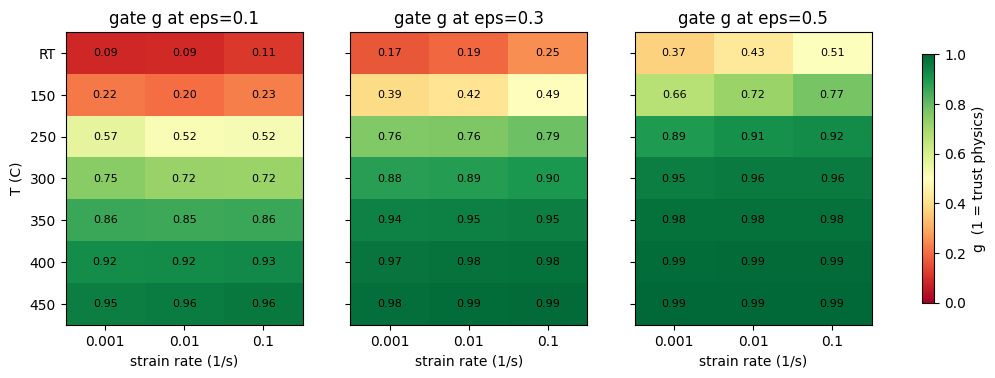

Mean gate per condition (v16 two-sided prior: expect LOW <0.5 at RT/150, HIGH at 250-450):
cond
RT-0_001     0.105
RT-0_01      0.116
RT-0_1       0.165
150-0_01     0.227
150-0_001    0.235
150-0_1      0.288
250-0_01     0.644
250-0_001    0.660
250-0_1      0.702
300-0_01     0.821
300-0_001    0.827
300-0_1      0.847
350-0_001    0.916
350-0_01     0.923
350-0_1      0.939
400-0_001    0.954
400-0_01     0.961
400-0_1      0.967
450-0_001    0.975
450-0_01     0.979
450-0_1      0.981


In [16]:
seed_everything(CFG.seed)
tr,va,te = random_split(CFG.seed)
Fg = prep_fold(tr,va,te)
mg,_ = train_model(Fg, active=("gate2",), weighting="fixed", lambdas={"gate2": CFG.lambda_gate},
                   seed=CFG.seed, run_name="gatemap", model_kind="hybrid")

temps_C = [25,150,250,300,350,400,450]
srs = [0.001,0.01,0.1]
eps_levels = [0.10,0.30,0.50]
fig, axes = plt.subplots(1, len(eps_levels), figsize=(13,3.8), sharey=True)
for ax, e0 in zip(np.atleast_1d(axes), eps_levels):
    G = np.zeros((len(temps_C), len(srs)))
    for i, Tc in enumerate(temps_C):
        for j, s0 in enumerate(srs):
            raw = _featurize(np.array([Tc+273.15],dtype=np.float32),
                             np.log(np.array([s0],dtype=np.float32)),
                             np.array([e0],dtype=np.float32), Fg.feature_mode, Fg.Q0)
            xs = torch.tensor(Fg.sx.transform(raw).astype(np.float32), device=Fg.device)
            with torch.no_grad():
                G[i,j] = float(mg.gate_value(xs))
    im = ax.imshow(G, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(len(srs))); ax.set_xticklabels([str(s) for s in srs])
    ax.set_yticks(range(len(temps_C))); ax.set_yticklabels(["RT" if t==25 else t for t in temps_C])
    ax.set_title(f"gate g at eps={e0}"); ax.set_xlabel("strain rate (1/s)")
    for i in range(G.shape[0]):
        for j in range(G.shape[1]):
            ax.text(j, i, f"{G[i,j]:.2f}", ha="center", va="center", fontsize=8)
np.atleast_1d(axes)[0].set_ylabel("T (C)")
fig.colorbar(im, ax=np.atleast_1d(axes).tolist(), shrink=0.85, label="g  (1 = trust physics)")
plt.savefig(f"{CFG.output_dir}/fig_stepC_gate_map_gp2.png", dpi=200, bbox_inches="tight"); plt.show()

# mean gate per condition on the actual data points
xg = torch.tensor(Fg.sx.transform(Fg.X).astype(np.float32), device=Fg.device)
with torch.no_grad():
    gall = mg.gate_value(xg).cpu().numpy().flatten()
gdf = pd.DataFrame({"cond": cond_arr, "g": gall}).groupby("cond")["g"].mean().round(3)
print("Mean gate per condition (v16 two-sided prior: expect LOW <0.5 at RT/150, HIGH at 250-450):")
print(gdf.sort_values().to_string())


## 14 · SCAM Parameter Validation (learned vs classical, inside valid window)

In [17]:
# Train one full-data PGNN and compare learned Arrhenius params to SCAM where SCAM is valid.
tr, va, te = random_split(CFG.seed)
Fv = prep_fold(tr, va, te)
m_val, _ = train_model(Fv, seed=CFG.seed, run_name="PGNN/full", model_kind="pgnn")
idx_valid = np.where(SCAM_VALID)[0]
_, lp = predict(m_val, Fv, idx_valid)
ev = eps_raw[idx_valid]
print(f"Validation on {len(idx_valid)} SCAM-valid points (T>=250C, eps in [{CFG.scam_eps_min},{CFG.scam_eps_max}])")
print(f"{'param':<6}{'learned mean±std':>22}{'SCAM mean±std':>22}")
for k, div, unit in [("alpha",1,"1/MPa"),("n",1,""),("Q",1e3,"kJ/mol"),("lnA",1,"")]:
    lv = lp[k].flatten()/div
    sv = np.polyval(SCAM_POLY_COEFFS[k], ev)/div
    print(f"{k:<6}{lv.mean():>10.3f}±{lv.std():<8.3f}{sv.mean():>12.3f}±{sv.std():<8.3f} {unit}")
print("\nLiterature anchor: Q for Al hot working ~150-185 kJ/mol (self-diffusion ~142 kJ/mol).")

Validation on 435 SCAM-valid points (T>=250C, eps in [0.05,0.19])
param       learned mean±std         SCAM mean±std
alpha      0.025±0.001          0.019±0.000    1/MPa
n          5.768±0.110          5.633±0.460    
Q        179.790±1.736        157.431±3.416    kJ/mol
lnA       26.897±0.189         25.009±0.839    

Literature anchor: Q for Al hot working ~150-185 kJ/mol (self-diffusion ~142 kJ/mol).


## 15 · How to run

1. **Kaggle:** attach the data (`al6011_downsampled_full.xlsx`) **and** the v15 output CSVs
   (`stepC_loco_hybrid_raw.csv`, `stepC_loto_hybrid_raw.csv`, `stepC_random_hybrid_raw.csv`,
   `stepC_percondition_hybrid_raw.csv`) as input datasets. The merge cells find them automatically.
2. Set `quick=False` (default). Full run trains only `hybrid+gp2`: 168 LOCO + 56 LOTO + 8 random ≈ **2.5–3 h on GPU**
   (vs ~10 h for the full v15 sweep).
3. Smoke test first: `quick=True` (60 epochs, 2 folds) — a few minutes.
4. Outputs: `stepC_*_gp2_raw.csv` (same schema as v15 → can also be concatenated by hand),
   `fig_stepC_loco_gp2.png`, `fig_stepC_gate_map_gp2.png`.

**Expected v16 headline:** hybrid+gp2 ≥ pgnn everywhere, and ≈/≥ ann in the DSA folds —
"physics where physics is valid, data where it is not", with the regime boundary encoded from metallurgy.